In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("Agri_Data_Cleaned.csv")

target = "NDVI_Season_Mean"

df.head()

,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,...,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield
0,259,Bagerhat,Rabi,17.75,55.0,Wheat,December,Jan To March,April,200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,0.772201
1,421,Bagerhat,Rabi,20.50,60.0,Maize 2,December,Jan To March,April,946.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,2.247031
2,145439,Bagerhat,Rabi,26.00,72.5,Boro,November,Dec To March,April,268754.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,1.847881
3,627,Bagerhat,Rabi,20.50,80.0,Sweet Potato,November,Dec To March,April,2200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,3.508772
4,383,Bagerhat,Kharif 1,31.50,70.0,Mango,April,April To May,April To June,1913.0,...,42.5,2.481885,5.86,22.73,High Risk,1,28.431973,1,0,4.994778


In [39]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 4178
Columns: 51
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4178 entries, 0 to 4177
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Area                         4178 non-null   int64  
 1   District                     4178 non-null   object 
 2   Season                       4178 non-null   object 
 3   Avg Temp                     4178 non-null   float64
 4   Avg Humidity                 4178 non-null   float64
 5   Crop Name                    4178 non-null   object 
 6   Transplant                   4178 non-null   object 
 7   Growth                       4178 non-null   object 
 8   Harvest                      4178 non-null   object 
 9   Production                   4178 non-null   float64
 10  Max Temp                     4178 non-null   int64  
 11  Min Temp                     4178 non-null   float64
 12  Max Relative Humidity        4178 non-null   int64  


In [40]:
df["NDVI_Season_Mean"].describe()

count    4178.000000
mean        0.373689
std         0.106110
min         0.000000
25%         0.305881
50%         0.388850
75%         0.441558
max         0.695371
Name: NDVI_Season_Mean, dtype: float64

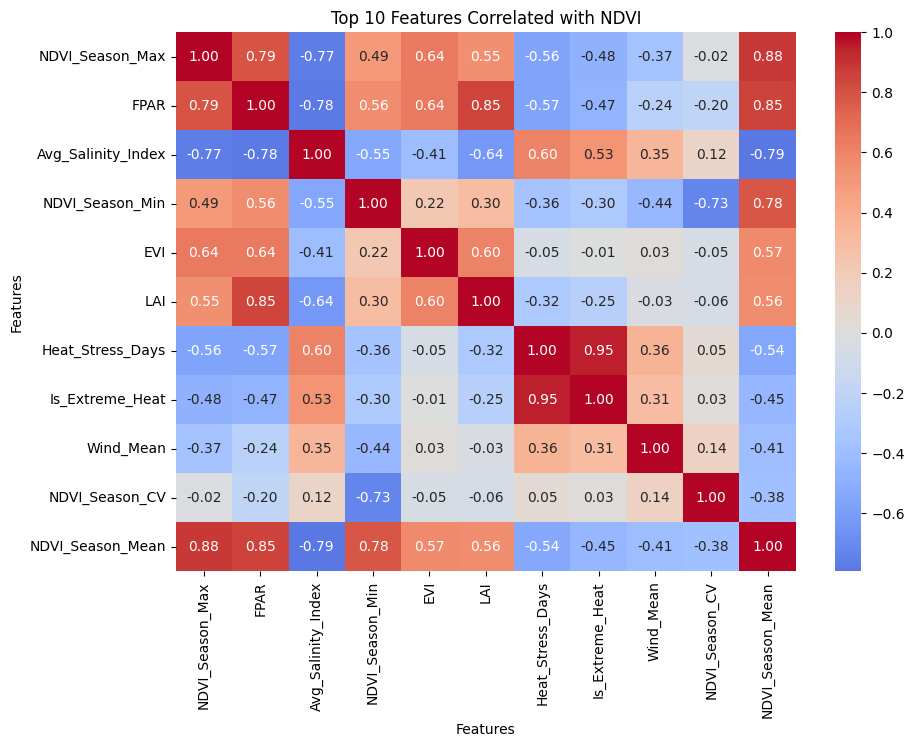

In [41]:
target = "NDVI_Season_Mean"

numeric_df = df.select_dtypes(include="number")

corr_with_target = numeric_df.corr()[target].drop(target)

top_features = (
    corr_with_target
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

cols = list(top_features) + [target]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Top 10 Features Correlated with NDVI")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_24800\862593842.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_ndvi.index, y=season_ndvi.values, palette="viridis")


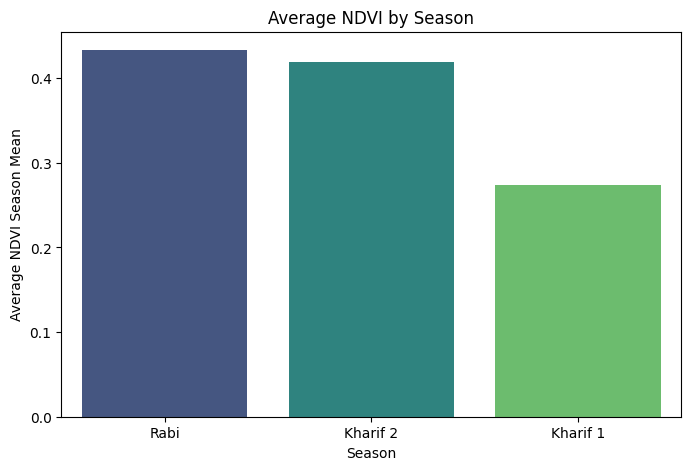

In [42]:
season_ndvi = df.groupby("Season")[target].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=season_ndvi.index, y=season_ndvi.values, palette="viridis")
plt.title("Average NDVI by Season")
plt.xlabel("Season")
plt.ylabel("Average NDVI Season Mean")
plt.show()

best_season = season_ndvi.idxmax()
worst_season = season_ndvi.idxmin()


C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_24800\152408863.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_ndvi.reset_index(), x="mean_ndvi", y="Crop Name", palette="mako")


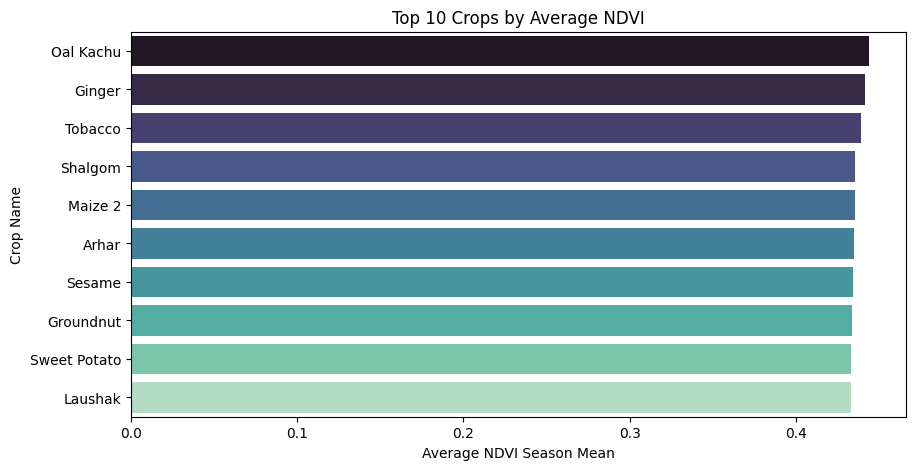

In [43]:
crop_ndvi = (
    df.groupby("Crop Name")
    .agg(mean_ndvi=(target, "mean"), count=(target, "count"))
    .query("count >= 20")
    .sort_values("mean_ndvi", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=crop_ndvi.reset_index(), x="mean_ndvi", y="Crop Name", palette="mako")
plt.title("Top 10 Crops by Average NDVI")
plt.xlabel("Average NDVI Season Mean")
plt.ylabel("Crop Name")
plt.show()


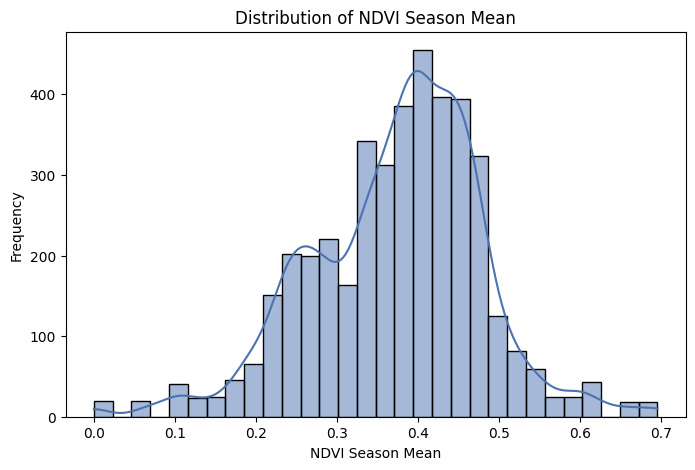

In [44]:
mean_ndvi = df[target].mean()
median_ndvi = df[target].median()

plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of NDVI Season Mean")
plt.xlabel("NDVI Season Mean")
plt.ylabel("Frequency")
plt.show()


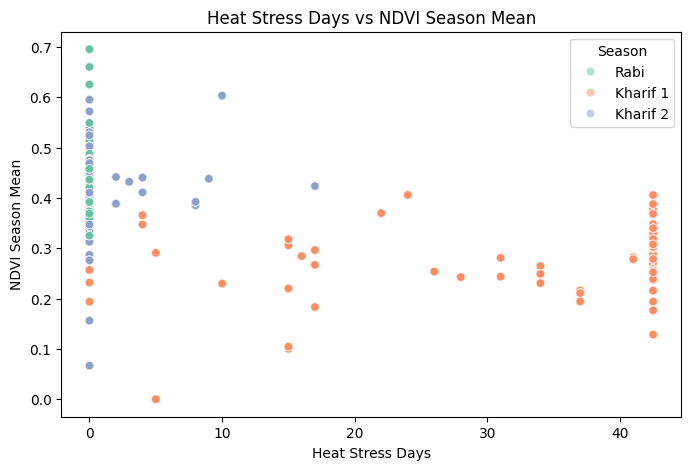

In [45]:
x_col = "Heat_Stress_Days"
corr_value = df[[x_col, target]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x_col, y=target, alpha=0.5, hue="Season", palette="Set2")
plt.title("Heat Stress Days vs NDVI Season Mean")
plt.xlabel("Heat Stress Days")
plt.ylabel("NDVI Season Mean")
plt.legend(title="Season")
plt.show()


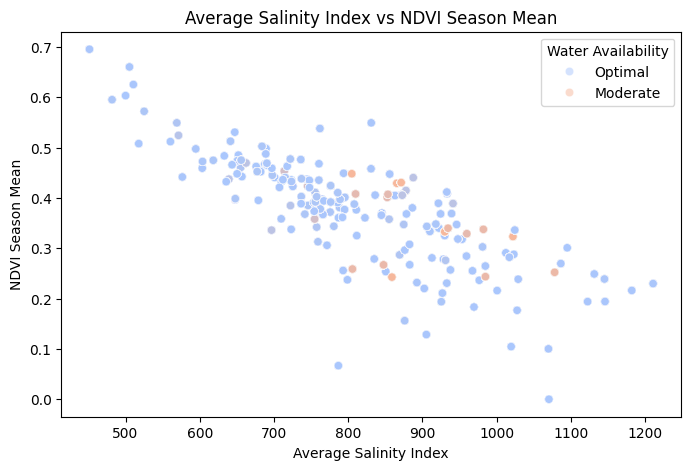

In [46]:
x_col = "Avg_Salinity_Index"
corr_value = df[[x_col, target]].corr().iloc[0, 1]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x_col, y=target, alpha=0.5, hue="Water_Availability_Cat", palette="coolwarm")
plt.title("Average Salinity Index vs NDVI Season Mean")
plt.xlabel("Average Salinity Index")
plt.ylabel("NDVI Season Mean")
plt.legend(title="Water Availability")
plt.show()


C:\Users\Gia Bao\AppData\Local\Temp\ipykernel_24800\1350070822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Extreme_Heat_Risk", y=target, palette="Set3")


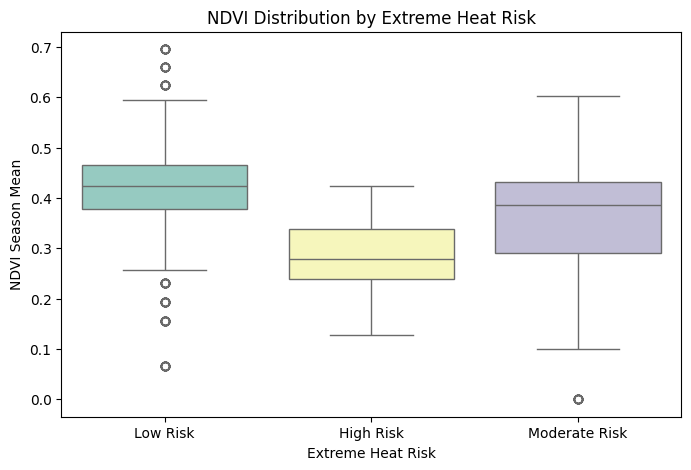

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Extreme_Heat_Risk", y=target, palette="Set3")
plt.title("NDVI Distribution by Extreme Heat Risk")
plt.xlabel("Extreme Heat Risk")
plt.ylabel("NDVI Season Mean")
plt.show()

risk_ndvi = df.groupby("Extreme_Heat_Risk")[target].median().sort_values(ascending=False)


In [48]:
fig = px.scatter(
    df,
    x="Soil_Moisture_mm",
    y=target,
    color="Season",
    hover_data=["Crop Name", "District", "Rainfall", "Heat_Stress_Days"],
    title="Interactive Scatter Plot: Soil Moisture vs NDVI"
)

fig.update_layout(
    xaxis_title="Soil Moisture (mm)",
    yaxis_title="NDVI Season Mean",
    legend_title="Season"
)

fig.show()
